Importações

In [1]:
!pip -q install plotly

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\pedro.lourega\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
!pip -q install yellowbrick


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: C:\Users\pedro.lourega\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

Leitura do CSV

In [ ]:
base_credit = pd.read_csv("content/credit_data.csv")
base_credit

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


Validação dos Dados

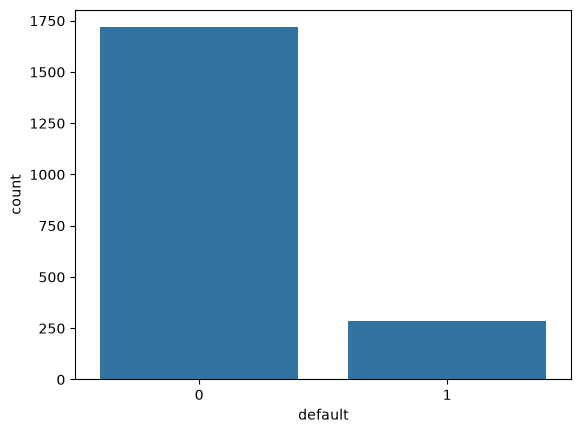

In [ ]:
np.unique(base_credit["default"], return_counts=True)

# gráfico padrão
sns.countplot(x=base_credit["default"]);

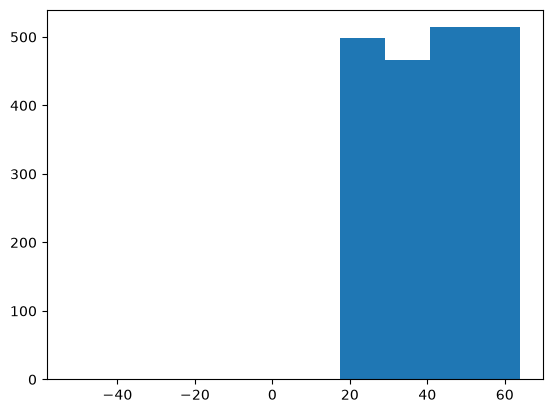

In [ ]:
# gráfico hist idade
plt.hist(x=base_credit["age"]);

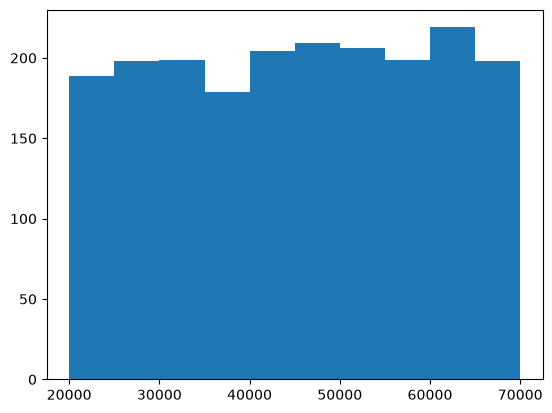

In [18]:
# gráfico tipo hist de renda
plt.hist(x=base_credit["income"]);

In [ ]:
grafico = px.scatter_matrix(
    base_credit, dimensions=["age", "income", "loan"], color="default"
)
grafico

Tratamento de Valores Inconsistentes

In [ ]:
base_credit.loc[base_credit["age"] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [40]:
# preencher valores inconsistentes

base_credit.mean()
base_credit["age"].mean()
media_age = base_credit["age"][base_credit["age"] > 0].mean()
base_credit.loc[base_credit["age"] < 0, "age"]

15   -28.218361
21   -52.423280
26   -36.496976
Name: age, dtype: float64

In [ ]:
base_credit2 = base_credit
base_credit2.loc[base_credit2["age"] < 0, "age"] = media_age

In [48]:
base_credit2

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0
